In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import yaml
import os
import glob
import random
import time
from collections import defaultdict

os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

sys.path.append("..")

import wandb
# import jax
from dataclasses import asdict
import numpy as np
import pandas as pd
import tqdm
# from agents import agents
# from ml_collections import FrozenConfigDict
#  from utils.datasets import Dataset, GCDataset, HGCDataset
# from utils.evaluation import evaluate
# from utils.flax_utils import restore_agent, save_agent
# from utils.log_utils import CsvLogger, get_exp_name, get_wandb_video, setup_wandb
from utils.config import GCTTTConfig, load_config
import matplotlib.pyplot as plt
import importlib
import re
from utils.plotting import plot_max_overall_success_vs_ttt_steps, plot_overall_success_for_groups

# Baselines 
For the three datsets,

Try both DDPG-BC and BC with the following learning rates:
- [3e-05, 3e-04, 5e-04, 1e-03, 3e-03, 4e-03, 1e-02]
- Report the best learning rate(s) for each policy extraction objective.



Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
BC lr3e-03                                          0.2080 ± 0.0315  0.9013 ± 0.0175  0.9453 ± 0.0058  0.9533 ± 0.0071  0.9053 ± 0.0178  0.9080 ± 0.0200  0.9533 ± 0.0071
DDPG-BC lr3e-04                                     0.2080 ± 0.0315  0.2067 ± 0.0398  0.2720 ± 0.0229  0.3040 ± 0.0353  0.3360 ± 0.0131  0.3467 ± 0.0110  0.3467 ± 0.0110
DDPG-BC lr5e-03                                     0.2140 ± 0.0467  0.5760 ± 0.0453  0.6020 ± 0.0580  0.5120 ± 0.0481  0.5700 ± 0.0523  0.5580 ± 0.0156  0.6020 ± 0.0580



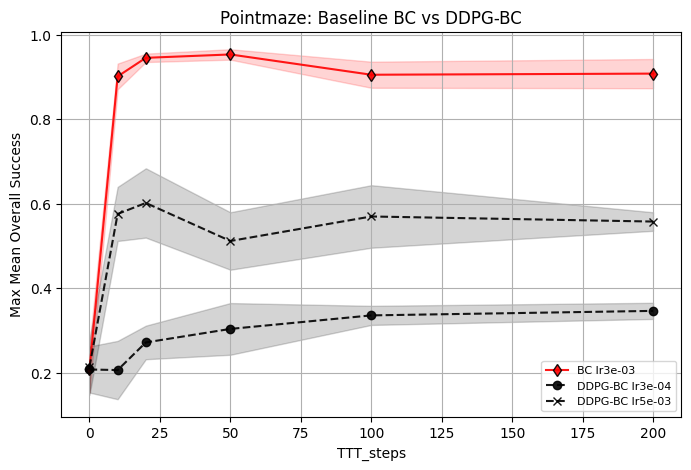

<Axes: title={'center': 'Pointmaze: Baseline BC vs DDPG-BC'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [4]:
# Pointmaze BASELINES
POINTMAZE_BASELINES = {
    "DDPG-BC lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"Pretrained lr5e-04": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained lr1e-03": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"Pretrained lr3e-03": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    "DDPG-BC lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"Pretrained lr1e-02": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "x",
    #},

    #"Pretrained BC lr3e-04": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #},

    #"Pretrained BC lr5e-04": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained BC lr1e-03": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    "BC lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    #"Pretrained BC lr5e-03": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #},

    #"Pretrained BC lr1e-02": {
    #    "groups": [
    #        "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "x",
    #}
}

plot_max_overall_success_vs_ttt_steps(POINTMAZE_BASELINES, title="Pointmaze: Baseline BC vs DDPG-BC", print_table=True)


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
BC lr1e-03                                          0.3333 ± 0.0381  0.7280 ± 0.0245  0.7467 ± 0.0175  0.7413 ± 0.0126  0.7080 ± 0.0118  0.7280 ± 0.0082  0.7467 ± 0.0175
DDPG-BC lr1e-03                                     0.3333 ± 0.0381  0.6653 ± 0.0165  0.6867 ± 0.0126  0.7053 ± 0.0095  0.6947 ± 0.0228  0.7160 ± 0.0182  0.7160 ± 0.0182
DDPG-BC lr3e-04                                     0.3333 ± 0.0381  0.6160 ± 0.0191  0.6400 ± 0.0180  0.6680 ± 0.0262  0.6960 ± 0.0255  0.7053 ± 0.0210  0.7053 ± 0.0210



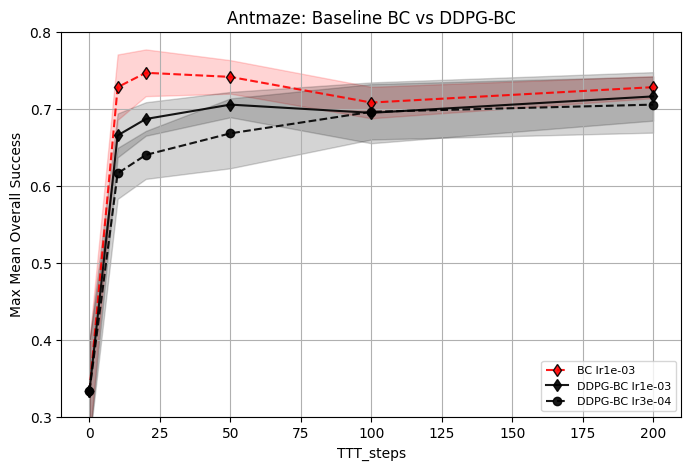

<Axes: title={'center': 'Antmaze: Baseline BC vs DDPG-BC'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [5]:
# Look at the baseline first
# Look at different learning rates


ANTMAZE_BASELINE = {
    "DDPG-BC lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"Pretrained lr5e-04": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    "DDPG-BC lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    #"Pretrained lr3e-03": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "X",
    #},

    #"Pretrained lr5e-03": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained lr1e-02": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"Pretrained BC lr3e-04": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #},

    #"Pretrained BC lr5e-04": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    "BC lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    #"Pretrained BC lr3e-03": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"Pretrained BC lr5e-03": {
    #    "groups": [
    #        "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #}
}
plot_max_overall_success_vs_ttt_steps(ANTMAZE_BASELINE, title="Antmaze: Baseline BC vs DDPG-BC", ylim=(0.3, 0.8), print_table=True)


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
BC lr3e-04                                          0.0853 ± 0.0076  0.3560 ± 0.0210  0.3560 ± 0.0163  0.4120 ± 0.0086  0.3853 ± 0.0158  0.3907 ± 0.0087  0.4120 ± 0.0086
DDPG-BC lr3e-04                                     0.0853 ± 0.0076  0.3640 ± 0.0151  0.4373 ± 0.0093  0.4480 ± 0.0212  0.4453 ± 0.0239  0.3960 ± 0.0115  0.4480 ± 0.0212



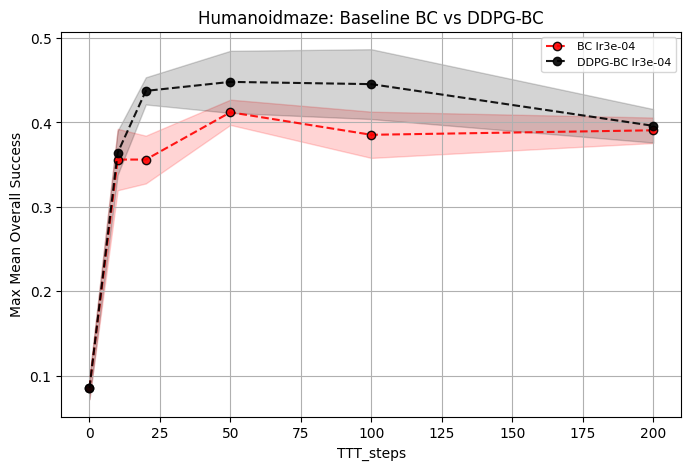

<Axes: title={'center': 'Humanoidmaze: Baseline BC vs DDPG-BC'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [6]:
HUMANOIDMAZE_DDPGBC_BC = {

    "DDPG-BC lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"Pretrained lr5e-04": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained lr1e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"Pretrained lr3e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"Pretrained lr5e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
    #    ],
    #    "color": "black",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #},

    #"Pretrained lr1e-02": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
    #    ],
    #    "color": "black",
    #    "linestyle": "-",
    #    "dot_type": "x",
    #},

    "BC lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    #"Pretrained BC lr5e-04": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"Pretrained BC lr1e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #    "dot_type": "d",
    #},

    #"Pretrained BC lr3e-03": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"Pretrained BC lr3e-05": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-05_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #    "dot_type": "x",
    #},

    #"Pretrained BC lr5e-05": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-05_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "-",
    #    "dot_type": "x",
    #},

    #"Pretrained BC lr1e-04": {
    #    "groups": [
    #        "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-04_TTT_actor_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #}
}
plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_DDPGBC_BC, reset=False, title="Humanoidmaze: Baseline BC vs DDPG-BC", print_table=True)

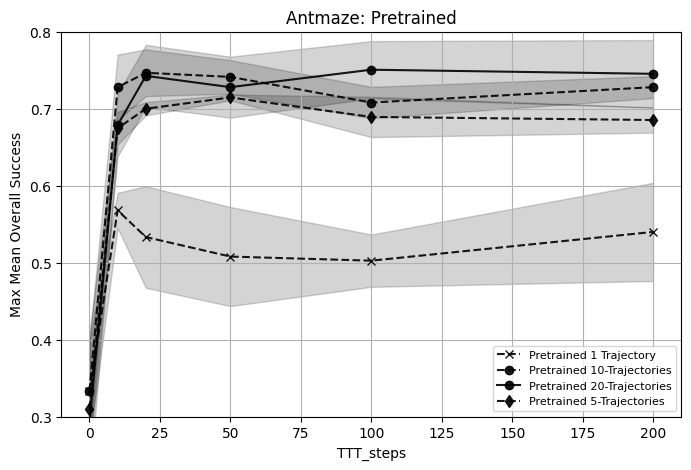

<Axes: title={'center': 'Antmaze: Pretrained'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [7]:
# Now, with the fixed learning rate (3e-04)
# Look at different num_trajectories used
# Look at the baseline first
# Look at different learning rates
ANTMAZE_BASELINE_TRAJ = {
    "Pretrained 1 Trajectory": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_actor_lossbc_traj_1"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained 5-Trajectories": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_actor_lossbc_traj_5"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },
    "Pretrained 10-Trajectories": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained 20-Trajectories": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_actor_lossbc_traj_20"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },
}
plot_max_overall_success_vs_ttt_steps(ANTMAZE_BASELINE_TRAJ, reset=False, title="Antmaze: Pretrained", ylim=(0.3, 0.8))

## Joint-training vs Fomaml vs Reptile
We assess the performance of such algorithms on the two more difficult datsets.


## Antmaze
DDPG-BC (I use 3e-04 as learning rate, but the best is 1e-03):
- Reptile:
- Fomaml: 
- Joint training:

Note: running with best learning rate 1e-03 (in progress).

BC (best learning rate 1e-03):
- Reptile: (1, 5, 10, 20, 50, 100, 200)
- Fomaml: (1, 5, 10, 20, 50, 100, 200)
- Joint Training: In progress (TODO: evaluate)
- RRAB todo ([25000, ..., 50000]), JTAB in progress, FFAB todo


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-FOMAML-actor 200-inner lr3e-04              0.3067 ± 0.0467  0.7067 ± 0.0029  0.7347 ± 0.0170  0.7080 ± 0.0050  0.7240 ± 0.0124  0.7267 ± 0.0219  0.7347 ± 0.0170
All: FT-Joint-actor 5-inner lr3e-04                 0.6500 ± 0.0427  0.6173 ± 0.0061  0.6880 ± 0.0038  0.7080 ± 0.0173  0.7280 ± 0.0023  0.7380 ± 0.0127  0.7380 ± 0.0127
All: FT-Reptile-actor 10-inner eps=0.1 lr3e-04      0.4973 ± 0.0642  0.6540 ± 0.0196  0.6740 ± 0.0058  0.7240 ± 0.0330  0.7100 ± 0.0173  0.7053 ± 0.0276  0.7240 ± 0.0330
Pretrained lr1e-03                                  0.3333 ± 0.0381  0.6653 ± 0.0165  0.6867 ± 0.0126  0.7053 ± 0.0095  0.6947 ± 0.0228  0.7160 ± 0.01

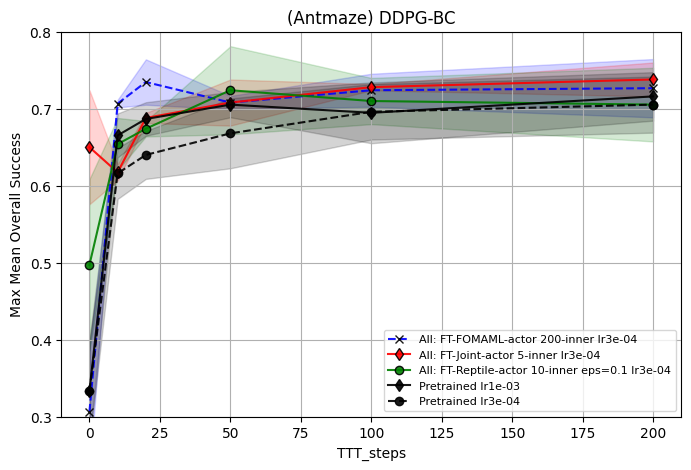

<Axes: title={'center': '(Antmaze) DDPG-BC'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [8]:
NEW_REPTILE_ALL = {
    #"All: FT-Reptile-actor 1-inner eps=0.1 lr3e-04": {
    #    "groups": [
    #        "FT-ALL-antmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #    "dot_type": "o",
    #},

    #"All: FT-Reptile-actor 5-inner eps=0.1 lr3e-04": {
    #    "groups": [
    #        "FT-ALL-antmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},

    "All: FT-Reptile-actor 10-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-10-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    #"All: FT-Reptile-actor 20-inner eps=0.1 lr3e-04": {
    #    "groups": [
    #        "FT-ALL-antmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},

    #"All: FT-Reptile-actor 50-inner eps=0.1 lr3e-04": {
    #    "groups": [
    #        "FT-ALL-antmaze-ddpgbc-RRAFIX-50-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},

    #"All: FT-Reptile-actor 100-inner eps=0.1 lr3e-04": {
    #    "groups": [
    #        "FT-ALL-antmaze-ddpgbc-RRAFIX-100-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #},

    #"All: FT-Reptile-actor 200-inner eps=0.1 lr3e-04": {
    #    "groups": [
    #        "FT-ALL-antmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #},

    "All: FT-FOMAML-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in NEW_REPTILE_ALL.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(NEW_REPTILE_ALL, reset=False, title="(Antmaze) DDPG-BC", ylim=(0.3, 0.8), print_table=True)


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-FOMAML-actor 10-inner lr1e-03               0.0000 ± 0.0000  0.4213 ± 0.0487  0.1960 ± 0.0529  0.5653 ± 0.0368  0.6453 ± 0.0357  0.6627 ± 0.0289  0.6627 ± 0.0289
All: FT-FOMAML-actor 20-inner lr1e-03               0.0000 ± 0.0000  0.0000 ± 0.0000  0.3120 ± 0.0094  0.4040 ± 0.0082  0.5373 ± 0.0202  0.5907 ± 0.0348  0.5907 ± 0.0348
All: FT-FOMAML-actor 5-inner lr1e-03                0.0000 ± 0.0000  0.2000 ± 0.0226  0.5120 ± 0.0339  0.6560 ± 0.0141  0.6640 ± 0.0085  0.6820 ± 0.0156  0.6820 ± 0.0156
All: FT-Reptile-actor 10-inner eps=0.1 lr1e-03      0.3720 ± 0.0731  0.6907 ± 0.0095  0.6947 ± 0.0158  0.7133 ± 0.0107  0.7080 ± 0.0309  0.7120 ± 0.03

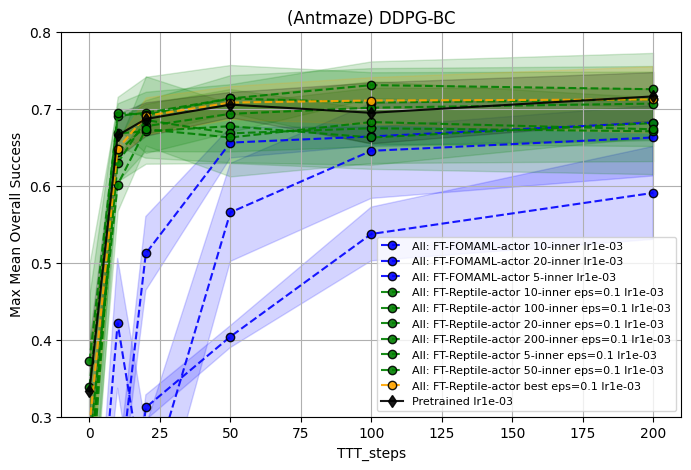

<Axes: title={'center': '(Antmaze) DDPG-BC'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [9]:
ANTMAZE_DDPGBC_BEST_LR = {
    "All: FT-Reptile-actor 5-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 10-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 20-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 50-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 100-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-100-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 200-inner eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRA-200-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },


    "All: FT-Reptile-actor best eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "orange",
        "linestyle": "--",
    },


    "All: FT-FOMAML-actor 5-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 10-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFA-20-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC_BEST_LR.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(ANTMAZE_DDPGBC_BEST_LR, reset=False, title="(Antmaze) DDPG-BC", ylim=(0.3, 0.8), print_table=True)


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-Fomaml-actor best lr1e-03                   0.3413 ± 0.0460  0.7427 ± 0.0154  0.7547 ± 0.0142  0.7587 ± 0.0058  0.7387 ± 0.0061  0.7813 ± 0.0097  0.7813 ± 0.0097
All: FT-JT-actor best lr1e-03                       0.4227 ± 0.0977  0.7320 ± 0.0151  0.7533 ± 0.0079  0.7440 ± 0.0132  0.7573 ± 0.0207  0.7520 ± 0.0191  0.7573 ± 0.0207
All: FT-Reptile-actor best eps=0.01 lr1e-03         0.3587 ± 0.0498  0.6613 ± 0.0175  0.6933 ± 0.0158  0.7307 ± 0.0157  0.7187 ± 0.0228  0.7160 ± 0.0197  0.7307 ± 0.0157
All: FT-Reptile-actor best eps=0.05 lr1e-03         0.3733 ± 0.0319  0.6747 ± 0.0203  0.6853 ± 0.0239  0.6947 ± 0.0225  0.7200 ± 0.0068  0.7360 ± 0.00

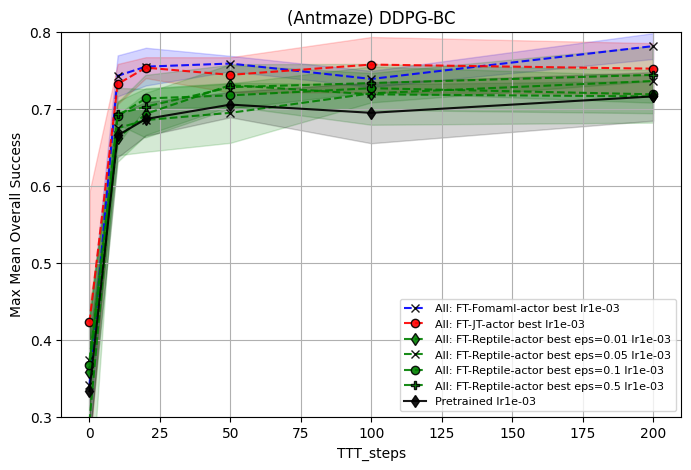

<Axes: title={'center': '(Antmaze) DDPG-BC'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [26]:
ANTMAZE_DDPGBC_BEST_LR = {
    "All: FT-Reptile-actor best eps=0.1 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor best eps=0.01 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.01-lr0.01-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "All: FT-Reptile-actor best eps=0.05 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.05-lr0.05-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "x",
    },


    #"All: FT-Reptile-actor best eps=0.2 lr1e-03": {
    #    "groups": [
    #        "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.2-lr0.2-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
    #    ],
    #    "color": "orange",
    #    "linestyle": "--",
    #    "dot_type": "P",
    #},


    "All: FT-Reptile-actor best eps=0.5 lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.5-lr0.5-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "P",
    },

    "All: FT-Fomaml-actor best lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    "All: FT-JT-actor best lr1e-03": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr1e-03_actor_lossddpgbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC_BEST_LR.items():
    pass #plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(ANTMAZE_DDPGBC_BEST_LR, reset=False, title="(Antmaze) DDPG-BC", ylim=(0.3, 0.8), print_table=True)


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-Fomaml-actor best lr3e-04                   0.3160 ± 0.0255  0.6827 ± 0.0061  0.7093 ± 0.0121  0.7213 ± 0.0061  0.7200 ± 0.0065  0.7133 ± 0.0123  0.7213 ± 0.0061
All: FT-JT-actor best lr3e-04                       0.3387 ± 0.0763  0.6867 ± 0.0270  0.6893 ± 0.0185  0.7507 ± 0.0191  0.7320 ± 0.0118  0.7267 ± 0.0171  0.7507 ± 0.0191
All: FT-Reptile-actor best eps=0.1 lr3e-04          0.2840 ± 0.0349  0.6240 ± 0.0295  0.6627 ± 0.0273  0.7027 ± 0.0193  0.7000 ± 0.0191  0.7000 ± 0.0150  0.7027 ± 0.0193
Pretrained lr3e-04                                  0.3333 ± 0.0381  0.6160 ± 0.0191  0.6400 ± 0.0180  0.6680 ± 0.0262  0.6960 ± 0.0255  0.7053 ± 0.02

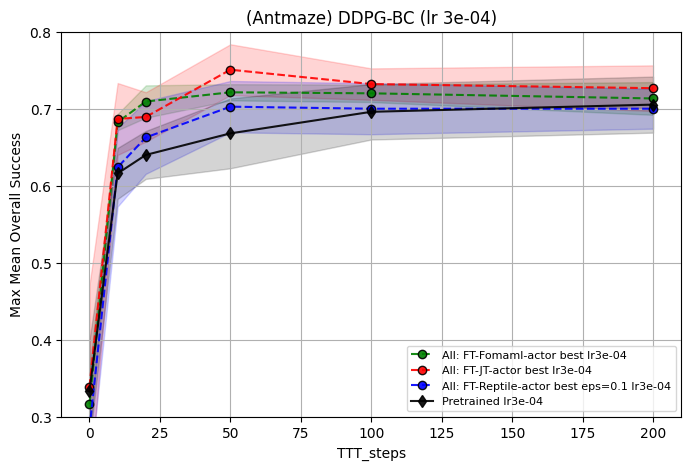

<Axes: title={'center': '(Antmaze) DDPG-BC (lr 3e-04)'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [11]:
ANTMAZE_DDPGBC = {
    "All: FT-Reptile-actor best eps=0.1 lr3e-04": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-RRAB-100-1-m_0.1-lr0.1-ilr3e-05_finetune_lr3e-04_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Fomaml-actor best lr3e-04": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-FFAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-JT-actor best lr3e-04": {
        "groups": [
            "antmaze_iql_ddpgbc/FT-ALL-antmaze-ddpgbc-JTAB-100-1-lr0.0003-ilr3e-05_finetune_lr3e-04_actor_lossddpgbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

}

for run_name, run_info in ANTMAZE_DDPGBC.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(ANTMAZE_DDPGBC, reset=False, title="(Antmaze) DDPG-BC (lr 3e-04)", ylim=(0.3, 0.8), print_table=True)

# Humanoidmaze


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-FOMAML-actor 1-inner lr3e-04                0.0760 ± 0.0115  0.4747 ± 0.0189  0.4947 ± 0.0207  0.5173 ± 0.0114  0.5093 ± 0.0160  0.5240 ± 0.0118  0.5240 ± 0.0118
All: FT-JTA-actor 20-inner lr3e-04                  0.1467 ± 0.0181  0.5000 ± 0.0314  0.5093 ± 0.0175  0.5280 ± 0.0278  0.5860 ± 0.0173  0.5213 ± 0.0134  0.5860 ± 0.0173
FT-Reptile-actor 50-inner eps=0.1                   0.0933 ± 0.0202  0.6347 ± 0.0268  0.6427 ± 0.0276  0.6867 ± 0.0089  0.6640 ± 0.0199  0.6640 ± 0.0065  0.6867 ± 0.0089
New Baseline Run                                    0.0853 ± 0.0076  0.3987 ± 0.0142  0.4200 ± 0.0105  0.4693 ± 0.0107  0.4880 ± 0.0161  0.5027 ± 0.01

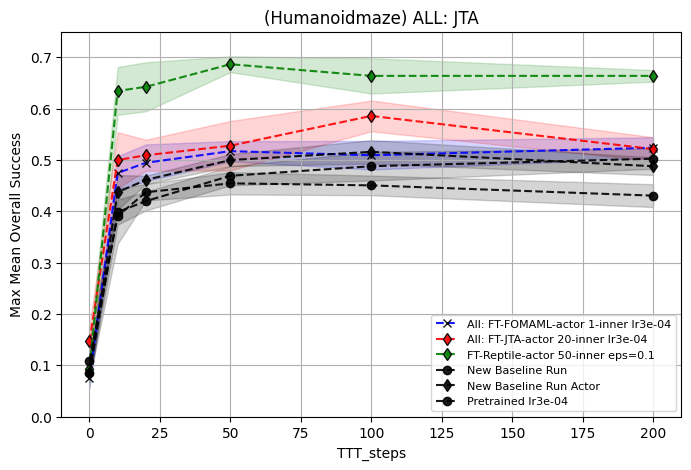

<Axes: title={'center': '(Humanoidmaze) ALL: JTA'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [15]:
HUMANOIDMAZE_JTA = {

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"All: FT-JTA-actor 200-inner lr3e-04": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    #"All: FT-Reptile-actor Best eps=0.15": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.15-lr0.15-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "-",
    #},

    "FT-Reptile-actor 50-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "New Baseline Run": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "New Baseline Run Actor": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_actor_lossddpgbc_TTT_actor"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },


    #"All: FT-Reptile-actor Best eps=1.0": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},
}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_JTA, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75), print_table=True)


Results Table: Max Overall Success vs TTT_steps
Label                                                             0               10               20               50              100              200              max
------------------------------------------------------------------------------------------------------------------------
All: FT-FOMAML-actor 1-inner lr3e-04                0.0760 ± 0.0115  0.4747 ± 0.0189  0.4947 ± 0.0207  0.5173 ± 0.0114  0.5093 ± 0.0160  0.5240 ± 0.0118  0.5240 ± 0.0118
All: FT-JTA-actor 20-inner lr3e-04                  0.1467 ± 0.0181  0.5000 ± 0.0314  0.5093 ± 0.0175  0.5280 ± 0.0278  0.5860 ± 0.0173  0.5213 ± 0.0134  0.5860 ± 0.0173
All: FT-Reptile-actor Best eps=0.15                 0.0560 ± 0.0068  0.6360 ± 0.0131  0.6440 ± 0.0180  0.6680 ± 0.0151  0.6667 ± 0.0208  0.6333 ± 0.0097  0.6680 ± 0.0151
FT-Reptile-actor 1-inner eps=0.1                    0.0853 ± 0.0076  0.4373 ± 0.0194  0.4613 ± 0.0047  0.5000 ± 0.0068  0.5160 ± 0.0132  0.4880 ± 0.01

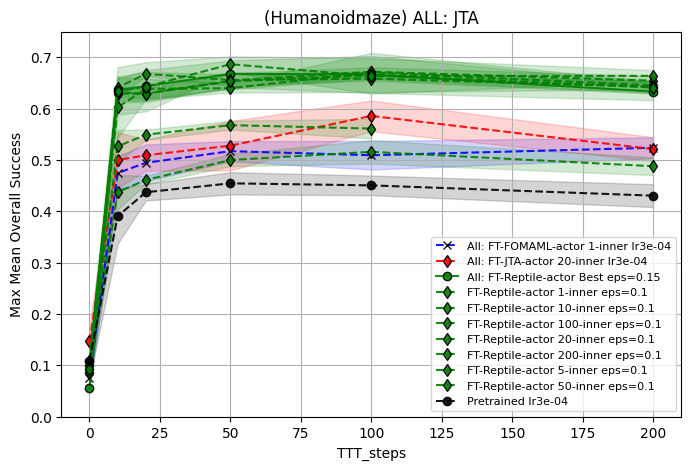

<Axes: title={'center': '(Humanoidmaze) ALL: JTA'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [5]:
HUMANOIDMAZE_JTA = {

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"All: FT-JTA-actor 200-inner lr3e-04": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    "All: FT-Reptile-actor Best eps=0.15": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.15-lr0.15-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "-",
    },

    "FT-Reptile-actor 1-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-1-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    "FT-Reptile-actor 5-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-5-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "FT-Reptile-actor 10-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-10-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "FT-Reptile-actor 20-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-20-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "FT-Reptile-actor 50-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "FT-Reptile-actor 100-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-100-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "FT-Reptile-actor 200-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-200-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    #"All: FT-Reptile-actor Best eps=1.0": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},
}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_JTA, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75), print_table=True)

In [ ]:
# Antmaze BC
ANTMAZE_BC = {

    #"RRAB 0.1": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.1-lr0.1-ilr0.001_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "--",
    #    "dot_type": "o",
    #},

    #"RRAB 0.2": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.2-lr0.2-ilr0.001_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},

    #"RRAB 0.5": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.05-lr0.05-ilr0.001_actor_lossbc"
    #    ],
    #    "color": "purple",
    #    "linestyle": "--",
    #},

    "FOMAML-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"FOMAML-actor 5-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "orange",
    #    "linestyle": "--",
    #},

    #"FOMAML-actor 10-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "orange",
    #    "linestyle": "--",
    #},

    "JT-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-JTA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    #"RRA 1-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-1-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #},

    "RRA 5-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    #"RRA 10-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "pink",
    #    "linestyle": "--",
    #},

    #"RRA 20-inner": {
    #    "groups": [
    #        "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-20-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_actor_lossbc"
    #    ],
    #    "color": "pink",
    #    "linestyle": "--",
    #},

    "Baseline lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

}

for run_name, run_info in ANTMAZE_BC.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(ANTMAZE_BC, reset=False, title="(Antmaze) BC", ylim=(0.3, 0.8))


# Pointmaze

DDPG-BC (Ignored?):
- Select best LR
- Reptile:
- Fomaml: 
- Joint training:

BC (best learning rate 1e-03):
- Reptile: (1, 5, 10, 20, 50, 100, 200)
- Fomaml: (1, 5, 10, 20, 50, 100, 200)
- Joint Training: In progress (TODO: evaluate)
- RRAB todo ([25000, ..., 50000]), JTAB in progress, FFAB todo

In [ ]:
# Pointmaze BASELINES
# TODO: evaluate for [25000, ..., 50000] RRAB
POINTMAZE_BC = {

    #"RRA 1-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-1-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "blue",
    #    "linestyle": "-",
    #},

    "RRA 5-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-5-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "-",
    },

    #"RRA 10-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-10-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #},

    #"RRA 20-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-20-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "--",
    #},

    "Reptile (50-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-50-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
    },

    #"RRA 100-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-100-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "green",
    #    "linestyle": "--",
    #},

    #"RRA 200-inner lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-200-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "purple",
    #    "linestyle": "--",
    #},

    "Fomaml (1-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },


    # TODO: add Joint training
    "Joint Training (1-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
    },

    "RRAB lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRAB-200-1-m_1e-05-lr1e-05-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },
}

for run_name, run_info in POINTMAZE_BC.items():
    pass #plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_BC, title="(Pointmaze) BC", print_table=True)

FileNotFoundError: Results directory not found: results_eval/pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-1-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc

In [ ]:
# Pointmaze BASELINES
# TODO: evaluate for [25000, ..., 50000] RRAB
POINTMAZE_BC_REPTILE = {

    "RRA 1-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-1-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "-",
    },

    "RRA 5-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-5-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "-",
    },

    "RRA 10-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-10-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "purple",
        "linestyle": "-",
    },

    "RRA 20-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-20-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Reptile (50-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-50-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "orange",
        "linestyle": "--",
    },

    "RRA 100-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-100-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "x",
    },

    "RRA 200-inner lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRA-200-1-m_0.0001-lr0.0001-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Fomaml (1-inner) lr3e-03": {
        "groups": [
            "pointmaze_iql_bc/FT-ALL-pointmaze-bc-FFA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    # TODO: add Joint training
    #Joint Training (1-inner) lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-JTA-1-1-lr0.0003-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "red",
    #    "linestyle": "-",
    #},

    #"RRAB lr3e-03": {
    #    "groups": [
    #        "pointmaze_iql_bc/FT-ALL-pointmaze-bc-RRAB-200-1-m_1e-05-lr1e-05-ilr0.003_finetune_lr3e-03_actor_lossbc"
    #    ],
    #    "color": "orange",
    #    "linestyle": "-",
    #},

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },
}

for run_name, run_info in POINTMAZE_BC_REPTILE.items():
    pass #plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_BC_REPTILE, title="(Pointmaze) BC", print_table=True, ylim=(0.8, 1.0))

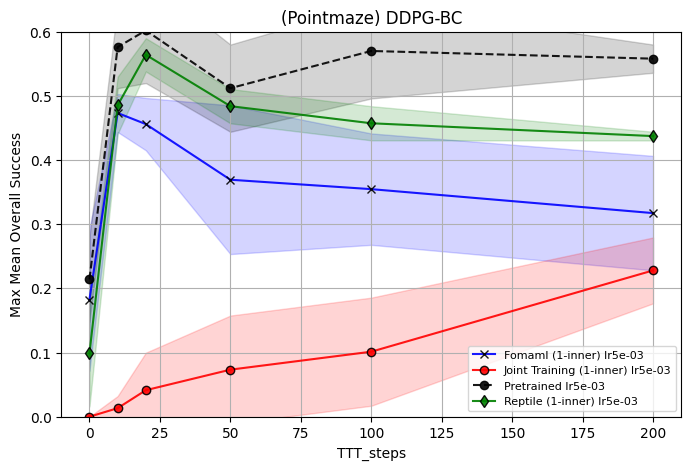

<Axes: title={'center': '(Pointmaze) DDPG-BC'}, xlabel='TTT_steps', ylabel='Max Mean Overall Success'>

In [12]:
# Pointmaze DDPG-BC
POINTMAZE_DDPGBC_BEST_LR = {

    "Fomaml (1-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-FFA-1-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Reptile (1-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-RRA-1-1-m_0.1-lr0.1-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Joint Training (1-inner) lr5e-03": {
        "groups": [
            "pointmaze_iql_ddpgbc/FT-ALL-pointmaze-ddpgbc-JTA-1-1-lr0.0003-ilr0.005_finetune_lr5e-03_actor_lossddpgbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}
for run_name, run_info in POINTMAZE_DDPGBC_BEST_LR.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_DDPGBC_BEST_LR, reset=False, title="(Pointmaze) DDPG-BC", ylim=(0, 0.6))


In [ ]:
# Pointmaze DDPG-BC
POINTMAZE_FOMAML = {

    "Fomaml (1-inner) lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Joint Training (1-inner) lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Reptile (20-inner) lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}
for run_name, run_info in POINTMAZE_FOMAML.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_FOMAML, reset=False, title="(Pointmaze) DDPG-BC", ylim=(0, 0.6))


# Early stopping strategy?

Pointmaze BC:

Antmaze BC:

Antmaze DDPG-BC:

Humanoidmaze DDPG-BC:



In [ ]:
HUMANOIDMAZE_EARLY_STOPPING = {

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    #"All: FT-JTA-actor 200-inner lr3e-04": {
    #    "groups": [
    #        "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
    #    ],
    #    "color": "purple",
    #    "linestyle": "-",
    #    "dot_type": "d",
    #},

    "All: FT-Reptile-actor Best eps=0.15": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.15-lr0.15-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "-",
    },

    "FT-Reptile-actor 50-inner eps=0.1": {
        "groups": [
            "humanoidmaze_iql_ddpgbc/FT-ALL-humanoidmaze-ddpgbc-RRA-50-1-m_0.1-lr0.1-ilr0.0003_actor_lossddpgbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    "All: FT-Reptile-actor Best eps=1.0": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },
}

for run_name, run_info in HUMANOIDMAZE_EARLY_STOPPING.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_EARLY_STOPPING, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75))

In [ ]:
RRB_ANTMAZE_BC_BEST_LR = {
    "Reptile Best eps 0.05": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.05-lr0.05-ilr0.001_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Reptile Best eps 0.1": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.1-lr0.1-ilr0.001_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Reptile Best eps 0.2": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRAB-200-1-m_0.2-lr0.2-ilr0.001_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}
plot_max_overall_success_vs_ttt_steps(RRB_ANTMAZE_BC_BEST_LR, reset=False, title="(Antmaze) BC Reptile-actor Early stopping", ylim=(0.3, 0.8))


In [ ]:
# TODO: evaluate these for steps 10000, 15000, 20000, ..., 50000
REPTILE_FOMAML_JTA_ANTMAZE_BC_BEST_LR = {
    "FOMAML-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "FOMAML-actor 5-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "FOMAML-actor 10-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Reptile-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-1-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Reptile-actor 5-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Reptile-actor 10-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    "JT-actor 1-inner": {
        "groups": [
            "antmaze_iql_bc/FT-ALL-antmaze-bc-JTA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}


for run_name, run_info in FOMAML_ALL_ACTOR_ONLY.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(REPTILE_FOMAML_JTA_ANTMAZE_BC_BEST_LR, reset=False, title="(Antmaze) BC Reptile-actor Early stopping", ylim=(0.3, 0.8))


# Ablations

In [ ]:
FOMAML_ALL_ACTOR_ONLY = {
    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "orange",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "X",
    },

    "Reptile Best": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },
    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}


for run_name, run_info in FOMAML_ALL_ACTOR_ONLY.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(NEW_FOMAML_ALL, reset=False, title="(Antmaze) ALL: Fomaml-actor", ylim=(0.3, 0.8))
plot_max_overall_success_vs_ttt_steps(FOMAML_ALL_ACTOR_ONLY, reset=False, title="(Antmaze) ALL: Fomaml-actor", ylim=(0.3, 0.8))


In [ ]:
JTA_ALL_ACTOR_ONLY = {
    "All: FT-Joint-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "All: FT-Joint-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}


plot_max_overall_success_vs_ttt_steps(JTA_ALL_ACTOR_ONLY, reset=False, title="(Antmaze) ALL: Joint-Training-actor", ylim=(0.3, 0.8))


In [ ]:
REPTILE_ALL_ACTOR_ONLY = {
    "All: FT-Reptile-actor 1-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 5-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 10-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-10-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 20-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 50-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-50-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 100-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-100-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 200-inner eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },


"Pretrained lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "X",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor best eps=0.05 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.05-lr0.05-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor best eps=0.1 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor best eps=0.2 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.2-lr0.2-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor best eps=0.5 lr3e-04": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAB-200-1-m_0.5-lr0.5-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },
}

plot_max_overall_success_vs_ttt_steps(REPTILE_ALL_ACTOR_ONLY, reset=False, title="(Antmaze) ALL: Reptile-actor", ylim=(0.3, 0.8))


In [ ]:
# Higher learning rate
REPTILE_ALL_ACTOR_ONLY_HIGHER_LR = {
    "All: FT-Reptile-actor 1-inner eps=0.1 lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.003_TTT_actor"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 5-inner eps=0.1 lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor only 1-inner eps=0.1 lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor only 5-inner eps=0.1 lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    }
}

plot_max_overall_success_vs_ttt_steps(REPTILE_ALL_ACTOR_ONLY_HIGHER_LR, reset=False, title="ALL: Reptile-actor", ylim=(0.3, 0.8))


In [ ]:
# Higher learning rate
FOMAML_ALL_ACTOR_ONLY_HIGHER_LR = {
    "All: FT-FOMAML-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.003_TTT_actor"
        ],
        "color": "purple",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.003_TTT_actor"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor only 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "--",
        "dot_type": "d",
    },

    "All: FT-FOMAML-actor only 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

plot_max_overall_success_vs_ttt_steps(FOMAML_ALL_ACTOR_ONLY_HIGHER_LR, reset=False, title="ALL: FOMAML-actor", ylim=(0.3, 0.8))


In [ ]:
# Higher learning rate
ANTMAZE_FOMAML_HIGHER_LR = {
    "All: FT-FOMAML-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-antmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "orange",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "X",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}


for run_name, run_info in ANTMAZE_FOMAML_HIGHER_LR.items():
    pass #plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(ANTMAZE_FOMAML_HIGHER_LR, reset=False, title="(Antmaze) ALL: Fomaml-actor", ylim=(0.3, 0.8))

# Pointmaze

In [ ]:
# Pointmaze BASELINES
POINTMAZE_BASELINES = {
    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

        "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Pretrained BC lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Pretrained BC lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained BC lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained BC lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained BC lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "x",
    }
}

plot_max_overall_success_vs_ttt_steps(POINTMAZE_BASELINES, title="(Pointmaze) Baselines:DDPGBC vs BC")

In [ ]:
POINTMAZE_FOMAML = {

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-FOMAML-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}
for run_name, run_info in POINTMAZE_FOMAML.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_FOMAML, reset=False, title="(Pointmaze) ALL: FOMAML-actor", ylim=(0, 0.6))


In [ ]:
POINTMAZE_FOMAML_HIGHER_LR = {

    "All: FT-FOMAML-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-FOMAML-actor 10-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "pink",
        "linestyle": "--",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

        "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    }
}

for run_name, run_info in POINTMAZE_FOMAML_HIGHER_LR.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_FOMAML_HIGHER_LR, reset=False, title="(Pointmaze) ALL: FOMAML-actor")

In [ ]:
POINTMAZE_JTA = {

    "All: FT-Joint-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Joint-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

for run_name, run_info in POINTMAZE_JTA.items():
    pass #plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_JTA, reset=False, title="(Pointmaze) ALL: Joint-Training-actor", ylim=(0, 0.6))


In [ ]:
POINTMAZE_JTA_HIGHER_LR = {

    "All: FT-Joint-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Joint-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Joint-actor 10-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 20-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 50-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 100-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-Joint-actor 200-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.003"
        ],
        "color": "pink",
        "linestyle": "-",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

for run_name, run_info in POINTMAZE_JTA_HIGHER_LR.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_JTA_HIGHER_LR, reset=False, title="(Pointmaze) ALL: Joint-Training-actor", ylim=(0, 0.6), error_bars=False)


In [ ]:
POINTMAZE_REPTILE = {

    "All: FT-Reptile-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Reptile-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-10-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-50-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-100-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "-",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

for run_name, run_info in POINTMAZE_REPTILE.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_REPTILE, reset=False, title="(Pointmaze) ALL: Reptile-actor", ylim=(0, 0.6))


In [ ]:
POINTMAZE_REPTILE_HIGHER_LR = {

    "All: FT-Reptile-actor 1-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-1-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor 5-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-5-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Reptile-actor 10-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-10-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 20-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-20-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 50-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-50-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 100-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-100-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "pink",
        "linestyle": "--",
    },

    "All: FT-Reptile-actor 200-inner lr3e-03": {
        "groups": [
            "FT-ALL-pointmaze-ddpgbc-RRAFIX-200-1-mc0.2-m_0.1-lr0.1-ilr0.003"
        ],
        "color": "pink",
        "linestyle": "-",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

        "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    }

}

for run_name, run_info in POINTMAZE_REPTILE_HIGHER_LR.items():
    pass #plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(POINTMAZE_REPTILE_HIGHER_LR, reset=False, title="(Pointmaze) ALL: Reptile-actor", ylim=(0, 0.6))


# Humanoidmaze (3 seeds)


In [ ]:
HUMANOIDMAZE_FOMAML = {

    "All: FT-FOMAML-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-FOMAML-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-FOMAML-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-FOMAML-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-FFA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "-",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}


HUMANOIDMAZE_JTA = {

    "All: FT-JTA-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-JTA-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-JTA-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "-",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    }
}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

for run_name, run_info in HUMANOIDMAZE_FOMAML.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_JTA, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75))
plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_FOMAML, reset=False, title="(Humanoidmaze) ALL: Fomaml", ylim=(0, 0.75))

In [ ]:
HUMANOIDMAZE_RRAB = {

    "All: FT-Reptile-actor Best eps=0.05": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.05-lr0.05-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    # NOTE: this one might be not up to date implementation
    "All: FT-Reptile-actor Best eps=0.1": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile-actor Best eps=0.15": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.15-lr0.15-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "--",
    },

    # NOTE: this one might be not up to date implementation
    "All: FT-Reptile-actor Best eps=0.2": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.2-lr0.2-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    # NOTE: this one might be not up to date implementation
    "All: FT-Reptile-actor Best eps=0.5": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-m_0.5-lr0.5-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },


    "All: FT-Reptile-actor Best eps=1.0": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRAB-200-1-lr1.0-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "--",
    },


    "All: FT-Reptile Best eps=0.05": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRB-200-1-m_0.05-lr0.05-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "-",
    },

    # NOTE: this one might be not up to date implementation
    "All: FT-Reptile Best eps=0.1": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRB-200-1-m_0.1-lr0.1-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-Reptile Best eps=0.15": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRB-200-1-m_0.15-lr0.15-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-Reptile Best eps=1.0": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-RRB-200-1-lr1.0-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "-",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    }
}

for run_name, run_info in HUMANOIDMAZE_RRAB.items():
    plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_RRAB, reset=False, title="(Humanoidmaze) ALL: RRAB", ylim=(0, 0.75))


In [ ]:
HUMANOIDMAZE_JTA = {

    "All: FT-JTA-actor 1-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "All: FT-JTA-actor 5-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "orange",
        "linestyle": "-",
    },

    "All: FT-JTA-actor 10-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 20-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "purple",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 50-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 100-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "brown",
        "linestyle": "--",
    },

    "All: FT-JTA-actor 200-inner lr3e-04": {
        "groups": [
            "FT-ALL-humanoidmaze-ddpgbc-JTA-200-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "pink",
        "linestyle": "-",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    }


}

for run_name, run_info in HUMANOIDMAZE_JTA.items():
    pass # plot_overall_success_for_groups({run_name: run_info})

plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_JTA, reset=False, title="(Humanoidmaze) ALL: JTA", ylim=(0, 0.75))

# DDPGCBC vs BC


In [ ]:
HUMANOIDMAZE_DDPGBC_BC = {

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Pretrained BC lr3e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained BC lr5e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained BC lr3e-03": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained BC lr3e-05": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-05_TTT_actor_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained BC lr5e-05": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-05_TTT_actor_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Pretrained BC lr1e-04": {
        "groups": [
            "RANDOM-humanoidmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-04_TTT_actor_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    }
}
plot_max_overall_success_vs_ttt_steps(HUMANOIDMAZE_DDPGBC_BC, reset=False, title="(Humanoidmaze) DDPGBC vs BC")

In [ ]:
# Pointmaze
POINTMAZE_DDPGBC_BC = {
    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

        "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "x",
    },

    "Pretrained BC lr3e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Pretrained BC lr5e-04": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained BC lr3e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained BC lr5e-03": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "x",
    },

    "Pretrained BC lr1e-02": {
        "groups": [
            "RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-02_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "x",
    }
}

plot_max_overall_success_vs_ttt_steps(POINTMAZE_DDPGBC_BC, reset=False, title="(Pointmaze) DDPGBC vs BC", print_table=True)

In [ ]:
ANTMAZE_DDPGBC_BC = {
        "Pretrained lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "X",
    },

    "Pretrained lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-BASELINE"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained BC lr3e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Pretrained BC lr5e-04": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-04_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "d",
    },

    "Pretrained BC lr3e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr3e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "-",
        "dot_type": "d",
    },

    "Pretrained BC lr5e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr5e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "x",
    }
}
plot_max_overall_success_vs_ttt_steps(ANTMAZE_DDPGBC_BC, reset=False, title="(Antmaze) DDPGBC vs BC", print_table=True)


In [ ]:
# Antmaze BC (with optimal learning rate)
ANTMAZE_BC = {
    "Pretrained BC lr1e-03": {
        "groups": [
            "RANDOM-antmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "d",
    },
    "REPTILE 1-inner": {
        "groups": [
            "FT-ALL-antmaze-bc-RRA-1-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "REPTILE 5-inner": {
        "groups": [
            "FT-ALL-antmaze-bc-RRA-5-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "REPTILE 10-inner": {
        "groups": [
            "FT-ALL-antmaze-bc-RRA-10-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "REPTILE 20-inner": {
        "groups": [
            "FT-ALL-antmaze-bc-RRA-20-1-m_0.1-lr0.1-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "red",
        "linestyle": "--",
    },

    "Fomaml 1 inner": {
        "groups": [
            "FT-ALL-antmaze-bc-FFA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "Fomaml 5 inner": {
        "groups": [
            "FT-ALL-antmaze-bc-FFA-5-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "Fomaml 10 inner": {
        "groups": [
            "FT-ALL-antmaze-bc-FFA-10-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "blue",
        "linestyle": "--",
    },

    "JT 1-inner": {
        "groups": [
            "FT-ALL-antmaze-bc-JTA-1-1-lr0.0003-ilr0.001_finetune_lr1e-03_TTT_actor_actor_lossbc"
        ],
        "color": "green",
        "linestyle": "--",
    }

}

plot_max_overall_success_vs_ttt_steps(ANTMAZE_BC, reset=False, title="(Antmaze) BC")